In [14]:
import xarray as xr
import rioxarray
from pathlib import Path
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.metrics import precision_score, recall_score, confusion_matrix
from scipy.ndimage import median_filter, minimum_filter, maximum_filter, uniform_filter
import lightgbm as lgb 
import geopandas as gpd
from matplotlib.ticker import StrMethodFormatter, MaxNLocator

import matplotlib.pyplot as plt
from shapely.geometry import Point
import seaborn as sns
from tqdm import tqdm
import joblib

In [15]:
from utils.constants import GH_TREE_COORDS_FILEPATH, SILVER_FOLDERPATH, GHANA_GDF

# Load Forestero's sites

In [16]:
df = pd.read_excel(GH_TREE_COORDS_FILEPATH)
df.head(3)

,Pays,Région,Region code,Site Nb,Site Name,Tree N.,Tree Latitude,Tree Longitude
0,Ghana,Central,CR,1,FO05,T1,5.323065,-1.173049
1,Ghana,Central,CR,2,FO06,T1,5.431284,-1.157774
2,Ghana,Central,CR,3,FO07,T1,5.538543,-1.185850


In [17]:
# 155 sites, spread across 6 regions
print("# sites:", df["Site Name"].nunique())
print("# regions:", df["Région"].nunique())
print("# site per regions:")
df.groupby("Région")["Site Name"].nunique().sort_values()

# sites: 155
# regions: 6
# site per regions:


Région
Brong-Ahafo      15
Eastern          18
Central          20
Western-South    31
Ashanti          32
Western-North    39
Name: Site Name, dtype: int64

In [18]:
# Add points
df["point"] = df.apply(axis=1, func=lambda row: Point((row["Tree Longitude"], row["Tree Latitude"])))
gdf = gpd.GeoDataFrame(df, geometry="point", crs="EPSG:4326")
gdf.head(3)

,Pays,Région,Region code,Site Nb,Site Name,Tree N.,Tree Latitude,Tree Longitude,point
0,Ghana,Central,CR,1,FO05,T1,5.323065,-1.173049,POINT (-1.17305 5.32306)
1,Ghana,Central,CR,2,FO06,T1,5.431284,-1.157774,POINT (-1.15777 5.43128)
2,Ghana,Central,CR,3,FO07,T1,5.538543,-1.185850,POINT (-1.18585 5.53854)


<Axes: title={'center': '775 trees provided by Forestero, on Ghana'}, xlabel='Lon', ylabel='Lat'>

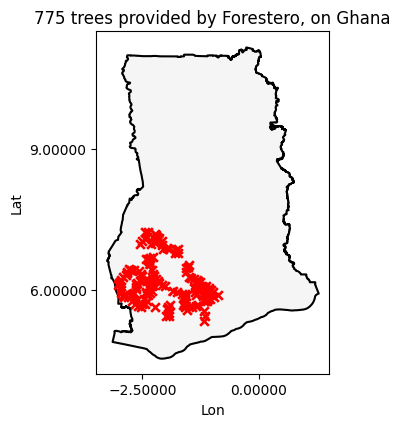

In [19]:
# Plot all sites
f = plt.figure(figsize=(3, 5))
ax = plt.gca()

# Make the lon/lat easier to read
ax.xaxis.set_major_locator(MaxNLocator(nbins=2))
ax.yaxis.set_major_locator(MaxNLocator(nbins=2))
ax.xaxis.set_major_formatter(StrMethodFormatter("{x:.5f}"))
ax.yaxis.set_major_formatter(StrMethodFormatter("{x:.5f}"))
plt.xlabel('Lon')
plt.ylabel('Lat')
plt.title(f"{len(gdf)} trees provided by Forestero, on Ghana")

# Plot full map
GHANA_GDF.plot(ax=ax,color="whitesmoke", edgecolor="black", linewidth=1.5)
gdf.plot(ax=ax, marker='x', c='r', alpha=0.8)